In [ ]:
import os
import glob
from pathlib import Path
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import timm  


In [ ]:
from sklearn.metrics import confusion_matrix

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class BreaKHisDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

import os
import glob
from pathlib import Path

def get_image_paths_and_labels(root_dir):
    file_paths = []
    labels = []
    
    class_mapping = {
        'SOB_B_A': 0,   
        'SOB_B_F': 1,   
        'SOB_B_PT': 2,   
        'SOB_B_TA': 3,  
        'SOB_M_DC': 4,   
        'SOB_M_LC': 5,   
        'SOB_M_MC': 6,   
        'SOB_M_PC': 7    
    }
    
    img_extensions = ('.png', '.jpg', '.jpeg')
    
    for class_dir in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_dir)
        
        if not os.path.isdir(class_path):
            continue
            
        if class_dir in class_mapping:
            label = class_mapping[class_dir]
        else:
            print(f"Skipping unknown directory: {class_dir}")
            continue
            
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(img_extensions):
                file_paths.append(os.path.join(class_path, img_file))
                labels.append(label)
    
    print(f"Found {len(file_paths)} images across {len(class_mapping)} classes.")
    print("Class distribution:", np.bincount(labels))
    return file_paths, labels, list(class_mapping.keys())

In [5]:
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

In [6]:
train_transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])


In [7]:
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dir = "/kaggle/input/final1/balanced_dataset"
train_paths, train_labels, class_names = get_image_paths_and_labels(train_dir)
train_dataset = BreaKHisDataset(train_paths, train_labels, train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dir = "/kaggle/input/split-data/BreakHis_splits/val/"
val_paths, val_labels, _ = get_image_paths_and_labels(val_dir)
val_dataset = BreaKHisDataset(val_paths, val_labels, test_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dir = "/kaggle/input/split-data/BreakHis_splits/test/"
test_paths, test_labels, _ = get_image_paths_and_labels(test_dir)
test_dataset = BreaKHisDataset(test_paths, test_labels, test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Found 8000 images across 8 classes.
Class distribution: [1000 1000 1000 1000 1000 1000 1000 1000]
Found 400 images across 8 classes.
Class distribution: [50 50 50 50 50 50 50 50]
Found 800 images across 8 classes.
Class distribution: [100 100 100 100 100 100 100 100]


In [8]:
!ls /kaggle/input/swin98/pytorch/default/1/best_swin_model.pth

/kaggle/input/swin98/pytorch/default/1/best_swin_model.pth


In [9]:
import os

model_dir = '/kaggle/input/swin_done'

for root, dirs, files in os.walk(model_dir):
    for name in files:
        print(os.path.join(root, name))

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
state_dict = torch.load('/kaggle/input/swin98/pytorch/default/1/best_swin_model.pth', map_location=device)

for k in list(state_dict.keys())[:10]:
    print(k)


/tmp/ipykernel_31/3432424356.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/kaggle/input/swin98/pytorch/default/1/best_swin_model.pth', map_lo

epoch
model_state_dict
optimizer_state_dict
scheduler_state_dict
best_val_acc


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim  
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class_names = [
    'adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma',
    'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma'
]


class SwinTeacher(nn.Module):
    def __init__(self, num_classes=8):
        super(SwinTeacher, self).__init__()
        self.model = models.swin_b(weights=None)
        self.model.head = nn.Linear(1024, num_classes)
        
        pretrained_weights = torch.load(
            "/kaggle/input/swin98/pytorch/default/1/best_swin_model.pth",
            map_location=device,
            weights_only=True
        )
        pretrained_weights.pop('swin.head.weight', None)
        pretrained_weights.pop('swin.head.bias', None)
        self.model.load_state_dict(pretrained_weights, strict=False)
        
        for param in self.model.parameters():
            param.requires_grad = False
            
    def get_features(self, x):
        x = self.model.features(x)
        x = self.model.norm(x)
        x = x.permute(0, 3, 1, 2)
        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)
        return x
        
    def forward(self, x):
        return self.model(x)


In [13]:
class EfficientNetStudent(nn.Module):
    def __init__(self, num_classes=8):
        super(EfficientNetStudent, self).__init__()
        self.model = models.efficientnet_b3(weights='DEFAULT')
        self.model.classifier[1] = nn.Linear(1536, num_classes)
        
    def get_features(self, x):
        return self.model.features(x)
        
    def forward(self, x):
        return self.model(x)

In [14]:
class DistillationModel(nn.Module):
    def __init__(self, teacher, student):
        super(DistillationModel, self).__init__()
        self.teacher = teacher
        self.student = student
        
        self.teacher_feature_adapter = nn.Sequential(
            nn.Linear(1024, 1536),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        with torch.no_grad():
            teacher_features = self.teacher.get_features(x)
            teacher_logits = self.teacher(x)
            
        student_features = self.student.get_features(x)
        student_logits = self.student(x)
        
        adapted_teacher_features = self.teacher_feature_adapter(teacher_features)
        pooled_student_features = F.adaptive_avg_pool2d(student_features, (1, 1)).squeeze()
        
        return {
            'teacher_logits': teacher_logits,
            'student_logits': student_logits,
            'teacher_features': adapted_teacher_features,
            'student_features': pooled_student_features
        }


In [15]:
def train_model(train_loader, val_loader, num_epochs=50):
    teacher = SwinTeacher().to(device)
    student = EfficientNetStudent().to(device)
    model = DistillationModel(teacher, student).to(device)
    
    optimizer = optim.AdamW(student.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.1)
    criterion_cls = nn.CrossEntropyLoss()
    criterion_kd = nn.KLDivLoss(reduction='batchmean')
    criterion_feat = nn.MSELoss()
    
    best_val_loss = float('inf')
    patience_counter = 0
    temperature = 4.0
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            
            cls_loss = criterion_cls(outputs['student_logits'], labels)
            kd_loss = criterion_kd(
                F.log_softmax(outputs['student_logits']/temperature, dim=1),
                F.softmax(outputs['teacher_logits']/temperature, dim=1)
            ) * (temperature ** 2)
            feat_loss = criterion_feat(
                outputs['student_features'],
                outputs['teacher_features']
            )
            
            total_loss = cls_loss + 0.5*kd_loss + 0.1*feat_loss
            total_loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs['student_logits'].data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            running_loss += total_loss.item()
            train_acc = 100 * train_correct / train_total
            pbar.set_postfix({
                'loss': running_loss/(pbar.n+1),
                'train_acc': f'{train_acc:.2f}%'
            })
            
        epoch_loss = running_loss / len(train_loader)
        train_accuracy = 100 * train_correct / train_total
        
        val_loss, val_accuracy = evaluate_model(model, val_loader)
        val_accuracy *= 100
        
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1:02d}:')
        print(f'Train Loss: {epoch_loss:.4f} | Acc: {train_accuracy:.2f}%')
        print(f'Val Loss: {val_loss:.4f} | Acc: {val_accuracy:.2f}%')
        print('-' * 50)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(student.state_dict(), '/kaggle/working/swin98_eff.pth')
            print('Model improved - saved!')
        else:
            patience_counter += 1
            if patience_counter >= 10:
                print('Early stopping triggered')
                break

In [15]:
def evaluate_model(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)['student_logits']
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

/tmp/ipykernel_31/3617436218.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load('/kaggle/input/feature96/pytorch/default/1/swin98_eff.pth

Overall Accuracy: 96.75%
Benign Accuracy: 98.00%
Malignant Accuracy: 99.00%

Classification Report:
                     precision    recall  f1-score   support

           adenosis     1.0000    0.9800    0.9899       100
       fibroadenoma     0.9340    0.9900    0.9612       100
    phyllodes_tumor     0.9794    0.9500    0.9645       100
    tubular_adenoma     1.0000    0.9900    0.9950       100
   ductal_carcinoma     0.9394    0.9300    0.9347       100
  lobular_carcinoma     0.9510    0.9700    0.9604       100
 mucinous_carcinoma     0.9505    0.9600    0.9552       100
papillary_carcinoma     0.9898    0.9700    0.9798       100

           accuracy                         0.9675       800
          macro avg     0.9680    0.9675    0.9676       800
       weighted avg     0.9680    0.9675    0.9676       800


Confusion Matrix:
[[98  0  2  0  0  0  0  0]
 [ 0 99  0  0  0  1  0  0]
 [ 0  5 95  0  0  0  0  0]
 [ 0  1  0 99  0  0  0  0]
 [ 0  0  0  0 93  4  3  0]
 [ 0  0  0 

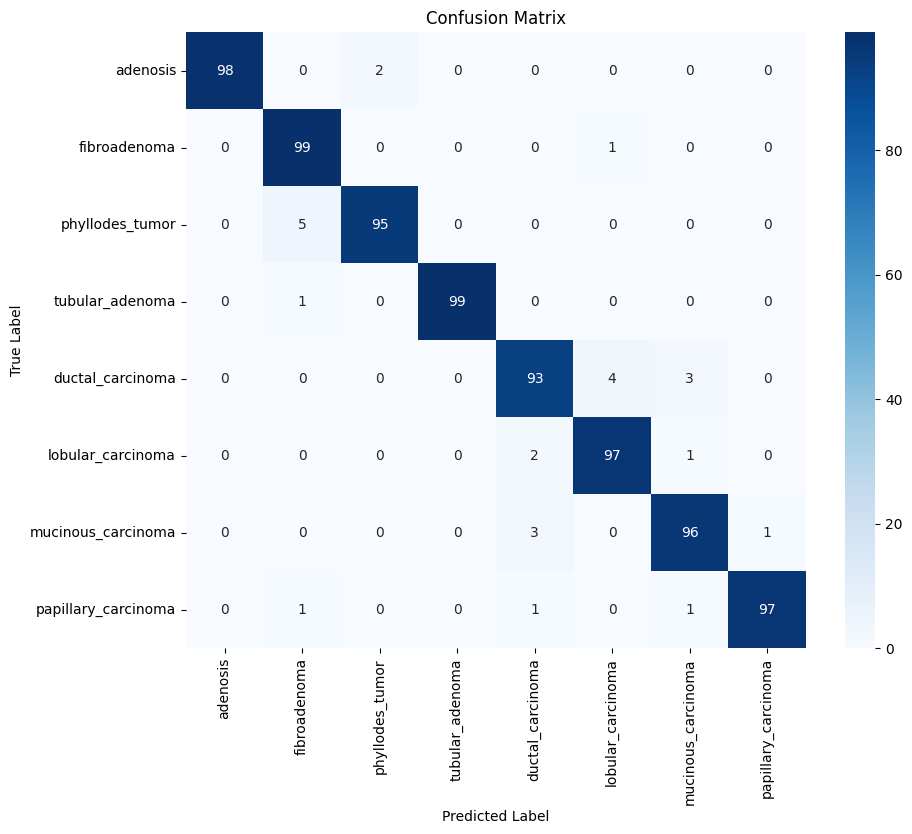


Correlation Matrix:
[[ 1.         -0.14785124 -0.13128266 -0.14785124 -0.15868645 -0.15132383
  -0.15309685 -0.15134237]
 [-0.14785124  1.         -0.09244125 -0.1345884  -0.15637424 -0.13798884
  -0.15135041 -0.13776636]
 [-0.13128266 -0.09244125  1.         -0.15243623 -0.16426451 -0.15664308
  -0.15847842 -0.15603562]
 [-0.14785124 -0.1345884  -0.15243623  1.         -0.15687624 -0.14959761
  -0.15135041 -0.14949625]
 [-0.15868645 -0.15637424 -0.16426451 -0.15687624  1.         -0.08644594
  -0.08875834 -0.14824789]
 [-0.15132383 -0.13798884 -0.15664308 -0.14959761 -0.08644594  1.
  -0.14226492 -0.15276247]
 [-0.15309685 -0.15135041 -0.15847842 -0.15135041 -0.08875834 -0.14226492
   1.         -0.13063205]
 [-0.15134237 -0.13776636 -0.15603562 -0.14949625 -0.14824789 -0.15276247
  -0.13063205  1.        ]]


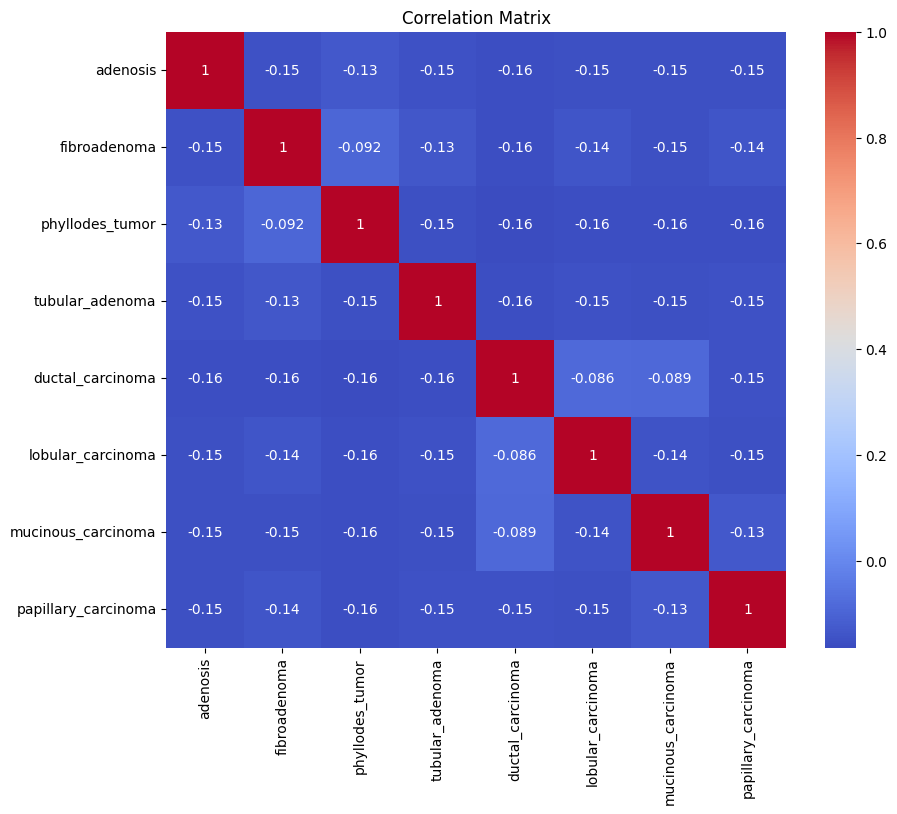

In [ ]:
def test_model(test_loader):
   
    student = EfficientNetStudent().to(device)
    student.load_state_dict(torch.load('/kaggle/input/feature96/pytorch/default/1/swin98_eff.pth', map_location=device))
    student.eval()
    
    all_preds = []
    all_labels = []
    
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = student(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    
    overall_acc = accuracy_score(all_labels, all_preds)
    print("Overall Accuracy: {:.2f}%".format(overall_acc * 100))
    
    
    benign_indices = [i for i, label in enumerate(all_labels) if label == 0]
    malignant_indices = [i for i, label in enumerate(all_labels) if label == 1]
    
    if benign_indices:
        benign_acc = accuracy_score([all_labels[i] for i in benign_indices],
                                    [all_preds[i] for i in benign_indices])
        print("Benign Accuracy: {:.2f}%".format(benign_acc * 100))
    else:
        print("No benign samples found for accuracy calculation.")
    
    if malignant_indices:
        malignant_acc = accuracy_score([all_labels[i] for i in malignant_indices],
                                       [all_preds[i] for i in malignant_indices])
        print("Malignant Accuracy: {:.2f}%".format(malignant_acc * 100))
    else:
        print("No malignant samples found for accuracy calculation.")
    
    
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    
    
    cm = confusion_matrix(all_labels, all_preds)
    print("\nConfusion Matrix:")
    print(cm)
    
   
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    
    corr_matrix = np.corrcoef(cm)
    print("\nCorrelation Matrix:")
    print(corr_matrix)
    
    
    plt.figure(figsize=(10,8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', xticklabels=class_names, yticklabels=class_names)
    plt.title('Correlation Matrix')
    plt.show()

def main():
                                          
    test_model(test_loader)               

if __name__ == '__main__':
    main()
